# Kalshi Paper Trading Bot — Analysis Notebook

Summarizes and compares the three backtestable strategies
(Favorite-Longshot, Momentum, Fair Value) using the CSVs produced by
`backtest.py`, `backtest_momentum.py`, `backtest_fair_value.py`, and
`compare_periods.py`. MeanReversion is excluded — it's TP/SL-based and
validated live only (see README).

This notebook is committed with its outputs already executed, so it renders
fully on GitHub without needing to run anything. To re-run it locally:
`pip install jupyter ipykernel && jupyter notebook analysis.ipynb`.


## Fill Model Fix

All three backtest engines originally priced trades at the **midpoint** of
Kalshi's quoted bid/ask, which is never actually fillable — buying YES costs
the ask, buying NO costs `1 - yes_bid`. That inflated apparent edge by
roughly half the spread on every trade. Caught by cross-checking this
project's own assumptions against Kalshi's real bid/ask mechanics rather
than trusting the code's own mental model, then fixed across all three
engines (executable price for every recorded outcome; fee rounded up to the
cent, matching Kalshi's real rounding).

Full before/after re-validation:

| Strategy | Metric | Before (mid-price) | After (executable price) |
|---|---|---|---|
| Momentum side=no | N=800 base | WR 75.8%, z=+2.14 | WR 65.7%, z=-0.31 |
| Momentum side=no | Out-of-sample (N=2000) | z=+2.16 | z=+1.43, EV/c ~ 0 |
| Fair Value side=no | N=800 base | N=120, WR 70.0%, z=+4.88 | N=31, WR 74.2%, z=+2.26 |
| Fair Value side=no | Out-of-sample (N~4000) | N=284, EV/c +0.224, z=+8.15 | N=233, EV/c +0.221, z=+7.30 |

**Momentum's edge was a mid-price artifact** and collapses under the
corrected model. **Fair Value's edge survives**, at essentially unchanged
effect size, on a smaller and more honestly-filtered sample. All CSVs loaded
below already reflect the corrected, executable-price fill model.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (11, 4)


## 1. Per-strategy backtest summary

One row per strategy, computed from its own results CSV.

In [2]:
from kalshi.backtest.metrics import (
    win_rate_with_ci as no_wr, ev_per_contract as no_ev,
    z_vs_implied as no_z, sharpe_ratio as no_sharpe,
)
from kalshi.backtest.common_metrics import (
    win_rate_with_ci as side_wr, ev_per_contract as side_ev,
    z_vs_implied as side_z, sharpe_ratio as side_sharpe,
)

longshot_df    = pd.read_csv("results/backtest_observations.csv")
momentum_df    = pd.read_csv("results/backtest_momentum.csv")
fair_value_df  = pd.read_csv("results/backtest_fair_value.csv")

longshot_obs   = longshot_df.assign(no_won=longshot_df["no_won"].astype(bool)).to_dict("records")
momentum_obs   = momentum_df.assign(side_won=momentum_df["side_won"].astype(bool)).to_dict("records")
fair_value_obs = fair_value_df.assign(side_won=fair_value_df["side_won"].astype(bool)).to_dict("records")


def _summary_row(name, obs, wr_fn, ev_fn, z_fn, sharpe_fn):
    wr, ci_lo, ci_hi = wr_fn(obs)
    sharpe = sharpe_fn(obs)
    return {
        "strategy": name, "n": len(obs), "win_rate": wr,
        "ci_lo": ci_lo, "ci_hi": ci_hi, "ev_per_contract": ev_fn(obs),
        "z_score": z_fn(obs),
        "sharpe_per_trade": sharpe["per_trade"],
        "sharpe_annualized": sharpe["annualized"],
    }

summary = pd.DataFrame([
    _summary_row("favorite_longshot", longshot_obs,   no_wr,   no_ev,   no_z,   no_sharpe),
    _summary_row("momentum",          momentum_obs,   side_wr, side_ev, side_z, side_sharpe),
    _summary_row("fair_value",        fair_value_obs, side_wr, side_ev, side_z, side_sharpe),
]).set_index("strategy")

summary.style.format({
    "win_rate": "{:.1%}", "ci_lo": "{:.1%}", "ci_hi": "{:.1%}",
    "ev_per_contract": "{:+.4f}", "z_score": "{:+.2f}",
    "sharpe_per_trade": "{:+.3f}", "sharpe_annualized": "{:+.2f}",
})


,n,win_rate,ci_lo,ci_hi,ev_per_contract,z_score,sharpe_per_trade,sharpe_annualized
strategy,,,,,,,,
favorite_longshot,421,21.4%,17.7%,25.5%,-0.0339,-1.03,-0.083,-15.87
momentum,800,66.8%,63.4%,69.9%,-0.0172,-0.10,-0.035,-9.27
fair_value,799,50.9%,47.5%,54.4%,-0.0009,+0.94,+0.001,+0.30


## 2. Side breakdown — Momentum & Fair Value

Both strategies can trade either side; the edge (if any) has so far been
concentrated on one side in each case.

In [3]:
def _side_breakdown(name, obs, wr_fn, ev_fn, z_fn):
    rows = []
    for side in ("yes", "no"):
        group = [o for o in obs if o["side"] == side]
        if not group:
            continue
        wr, ci_lo, ci_hi = wr_fn(group)
        rows.append({"strategy": name, "side": side, "n": len(group),
                     "win_rate": wr, "ev_per_contract": ev_fn(group), "z_score": z_fn(group)})
    return rows

side_df = pd.DataFrame(
    _side_breakdown("momentum", momentum_obs, side_wr, side_ev, side_z) +
    _side_breakdown("fair_value", fair_value_obs, side_wr, side_ev, side_z)
).set_index(["strategy", "side"])

side_df.style.format({"win_rate": "{:.1%}", "ev_per_contract": "{:+.4f}", "z_score": "{:+.2f}"})


## 3. Period comparison

Same three strategies, split by calendar month
(`compare_periods.py` → `results/period_comparison.csv`) — the
"favorite_longshot March 2026 / April 2026 / ..." view.

**Caveat:** this section predates the fill-model fix above (still shows
mid-price-based numbers) and separately has a real sampling bug — each
"month" is capped at 150 markets/series and the engines take the most
*recent* qualifying markets in a date range, so each "month" is actually
only its last ~1.5 days, not a representative average. Treat this section as
stale; regenerating `compare_periods.py`'s output with the corrected engine
is a follow-up, not done yet.

In [4]:
period_df = pd.read_csv("results/period_comparison.csv")
pivot_wr = period_df.pivot(index="period", columns="strategy", values="win_rate")
pivot_ev = period_df.pivot(index="period", columns="strategy", values="ev_per_contract")

display(period_df.set_index(["strategy", "period"]).style.format({
    "win_rate": "{:.1%}", "ev_per_contract": "{:+.4f}",
    "z_score": "{:+.2f}", "sharpe_per_trade": "{:+.3f}",
}))


,,n,win_rate,ev_per_contract,z_score,sharpe_per_trade
strategy,period,,,,,
favorite_longshot,2026-02,155,21.9%,-0.0251,-0.37,-0.061
momentum,2026-02,300,66.3%,-0.0184,-0.10,-0.038
fair_value,2026-02,300,60.3%,+0.1185,+4.72,+0.260
favorite_longshot,2026-03,176,19.9%,-0.0457,-1.04,-0.113
momentum,2026-03,300,68.7%,-0.0037,+0.43,-0.005
fair_value,2026-03,300,59.3%,+0.0833,+3.49,+0.181
favorite_longshot,2026-04,170,27.1%,+0.0225,+1.08,+0.052
momentum,2026-04,300,69.7%,+0.0198,+1.30,+0.050
fair_value,2026-04,300,56.7%,+0.0490,+2.30,+0.106


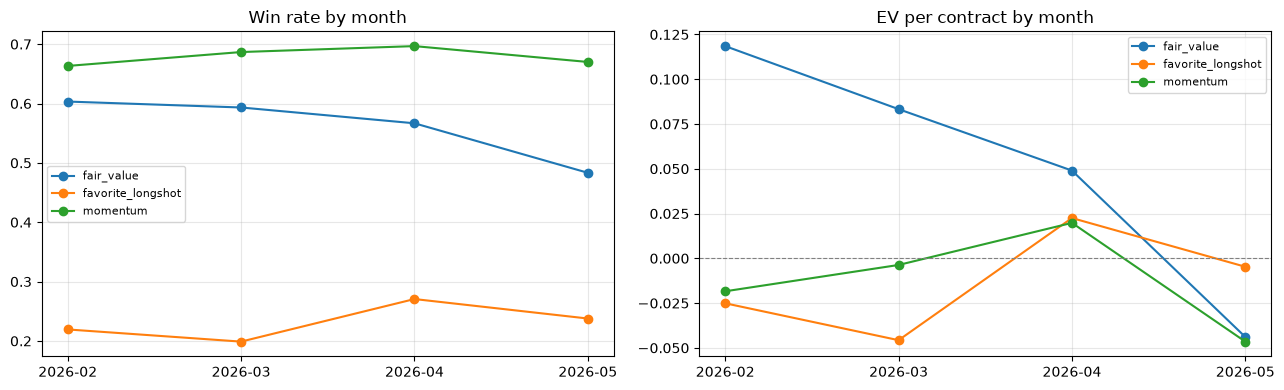

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for strategy in pivot_wr.columns:
    axes[0].plot(pivot_wr.index, pivot_wr[strategy], marker="o", label=strategy)
    axes[1].plot(pivot_ev.index, pivot_ev[strategy], marker="o", label=strategy)
axes[0].set_title("Win rate by month")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)
axes[1].axhline(0, color="gray", linewidth=0.8, linestyle="--")
axes[1].set_title("EV per contract by month")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
fig.tight_layout()


## 4. Out-of-sample validation

Train/test split on a held-out 2-week tail (`--test-after`), for the two
newer strategies' headline claims. This is the check that was explicitly
flagged as missing when those findings were first reported.

In [6]:
def _train_test_summary(path, wr_fn, ev_fn, z_fn, won_col):
    df = pd.read_csv(path)
    df[won_col] = df[won_col].astype(bool)
    rows = []
    for split in ("train", "test"):
        group = df[df["split"] == split].to_dict("records")
        if not group:
            continue
        wr, ci_lo, ci_hi = wr_fn(group)
        rows.append({"split": split, "n": len(group), "win_rate": wr,
                     "ev_per_contract": ev_fn(group), "z_score": z_fn(group)})
    return pd.DataFrame(rows).set_index("split")

print("Momentum - side=no (the borderline live finding), train vs test:")
mom_oos = pd.read_csv("results/backtest_momentum_oos.csv")
mom_oos["side_won"] = mom_oos["side_won"].astype(bool)
mom_no = mom_oos[mom_oos["side"] == "no"]
for split in ("train", "test"):
    g = mom_no[mom_no["split"] == split].to_dict("records")
    if g:
        wr, *_ = side_wr(g)
        print(f"  {split:<6} n={len(g):<4} WR={wr:.1%}  EV/c={side_ev(g):+.4f}  z={side_z(g):+.2f}")

print()
print("Fair Value - side=no (the standout z=4.88 finding), train vs test:")
fv_oos = pd.read_csv("results/backtest_fair_value_oos.csv")
fv_oos["side_won"] = fv_oos["side_won"].astype(bool)
fv_no = fv_oos[fv_oos["side"] == "no"]
for split in ("train", "test"):
    g = fv_no[fv_no["split"] == split].to_dict("records")
    if g:
        wr, *_ = side_wr(g)
        print(f"  {split:<6} n={len(g):<4} WR={wr:.1%}  EV/c={side_ev(g):+.4f}  z={side_z(g):+.2f}")


Momentum - side=no (the borderline live finding), train vs test:
  train  n=674  WR=66.5%  EV/c=-0.0126  z=+0.17
  test   n=1326 WR=71.6%  EV/c=+0.0061  z=+1.66

Fair Value - side=no (the standout z=4.88 finding), train vs test:
  train  n=65   WR=70.8%  EV/c=+0.2245  z=+3.91
  test   n=168  WR=69.6%  EV/c=+0.2197  z=+6.17


## 5. Fair Value — full month, uncapped (the headline result)

A full calendar month (May 2026) with no market cap
(`--max-markets 5000`, actual coverage 2,921-2,923 markets/series — the cap
was never binding, and date coverage was confirmed to span the whole month,
not a truncated tail). This is the largest, most representative sample
collected for any strategy in this project, run entirely on the corrected
fill model.

In [7]:
may_df = pd.read_csv("results/backtest_fair_value_may_full.csv")
may_df["side_won"] = may_df["side_won"].astype(bool)
may_obs = may_df.to_dict("records")

print(f"Coverage: {may_df['market_close_date'].min()} to {may_df['market_close_date'].max()}"
      f"  |  {may_df['series'].value_counts().to_dict()}")

may_summary = pd.DataFrame(
    _side_breakdown("fair_value (May, full month)", may_obs, side_wr, side_ev, side_z)
).set_index(["strategy", "side"])
may_summary.style.format({"win_rate": "{:.1%}", "ev_per_contract": "{:+.4f}", "z_score": "{:+.2f}"})


Coverage: 2026-05-01 to 2026-05-31  |  {'KXETH15M': 2923, 'KXBTC15M': 2921}
